Phẩn 1: Làm sạch dữ liệu bằng PYTHON (Thư viện Pandas)

Bước 1: Nạp dữ liệu và kiểm tra tổng quan

In [16]:
import pandas as pd
import numpy as np

# Đọc tệp tin đã tải lên bộ nhớ đệm (Session storage)
df = pd.read_csv('application_train.csv')

# Hiển thị 5 dòng đầu tiên để kiểm tra cấu trúc
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Bước 2: Kiểm tra tổng quan kích thước và kiểu dữ liệu
Tạo một ô mã nguồn tiếp theo để xem tổng số hàng, cột và các trường thông tin:

In [17]:
# Kiểm tra số lượng dòng và cột
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")

# Xem thông tin chi tiết về kiểu dữ liệu của từng cột
df.info(verbose=True, show_counts=True)

Số dòng: 128091, Số cột: 122
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128091 entries, 0 to 128090
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    128091 non-null  int64  
 1    TARGET                        128091 non-null  int64  
 2    NAME_CONTRACT_TYPE            128091 non-null  object 
 3    CODE_GENDER                   128091 non-null  object 
 4    FLAG_OWN_CAR                  128091 non-null  object 
 5    FLAG_OWN_REALTY               128091 non-null  object 
 6    CNT_CHILDREN                  128091 non-null  int64  
 7    AMT_INCOME_TOTAL              128091 non-null  float64
 8    AMT_CREDIT                    128091 non-null  float64
 9    AMT_ANNUITY                   128083 non-null  float64
 10   AMT_GOODS_PRICE               127990 non-null  float64
 11   NAME_TYPE_SUITE               127564 non-null  object 
 12  

Bước 3: Xác minh tính toàn vẹn - Kiểm tra trùng lặp (Duplicates)
Đảm bảo định danh duy nhất của khách hàng (SK_ID_CURR) không bị lặp lại:

In [18]:
# Kiểm tra số lượng ID trùng lặp
duplicate_count = df.duplicated(subset=['SK_ID_CURR']).sum()
print(f"Số lượng bản ghi trùng lặp theo ID: {duplicate_count}")

# Loại bỏ trùng lặp nếu có và giữ lại bản ghi đầu tiên
if duplicate_count > 0:
    df = df.drop_duplicates(subset=['SK_ID_CURR'], keep='first')

Số lượng bản ghi trùng lặp theo ID: 0


Bước 4: Xử lý điểm dị biệt hệ thống (Outliers)
Trường dữ liệu DAYS_EMPLOYED chứa giá trị lỗi hệ thống 365243 (tương đương khoảng 1000 năm làm việc). Phải chuyển giá trị dị biệt này về dạng dữ liệu trống (NaN) để không làm sai lệch các phép tính thống kê:

In [19]:
# Kiểm tra giá trị lớn nhất trước khi xử lý
print("Giá trị lớn nhất trước xử lý:", df['DAYS_EMPLOYED'].max())

# Thay thế giá trị lỗi bằng NaN
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Xác nhận lại sau khi thay thế
print("Giá trị lớn nhất sau xử lý:", df['DAYS_EMPLOYED'].max())

Giá trị lớn nhất trước xử lý: 365243
Giá trị lớn nhất sau xử lý: 0.0


Bước 5: Thống kê và đánh giá dữ liệu thiếu (Missing Values)
Xác định tỷ lệ trống của các trường thông tin nhằm phục vụ cho việc đưa ra quyết định loại bỏ hoặc điền khuyết dữ liệu ở các bước sau:

In [20]:
# Tính số lượng và tỷ lệ phần trăm dữ liệu thiếu trên từng cột
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

# Gom nhóm thành bảng thống kê và sắp xếp giảm dần
missing_table = pd.concat([missing_values, missing_percent], axis=1)
missing_table.columns = ['Số lượng thiếu', 'Tỷ lệ % thiếu']
missing_table = missing_table[missing_table['Số lượng thiếu'] > 0].sort_values(by='Tỷ lệ % thiếu', ascending=False)

# Hiển thị top 20 cột thiếu dữ liệu nhiều nhất
missing_table.head(20)

,Số lượng thiếu,Tỷ lệ % thiếu
COMMONAREA_AVG,89481,69.857367
COMMONAREA_MODE,89481,69.857367
COMMONAREA_MEDI,89481,69.857367
NONLIVINGAPARTMENTS_AVG,88887,69.393634
NONLIVINGAPARTMENTS_MODE,88887,69.393634
NONLIVINGAPARTMENTS_MEDI,88887,69.393634
LIVINGAPARTMENTS_AVG,87565,68.361555
LIVINGAPARTMENTS_MODE,87565,68.361555
LIVINGAPARTMENTS_MEDI,87565,68.361555
FONDKAPREMONT_MODE,87511,68.319398


Phần 2: Làm sạch dữ liệu bằng SQLĐể dùng SQL, bước đầu tiên là bạn cần nhập dữ liệu của mình (Import your data) vào công cụ quản trị cơ sở dữ liệu  như PostgreSQL, MySQL, hoặc MS SQL Server. Hãy tạo một bảng có tên application_train và import file CSV vào đó.  Sau khi nạp xong, chúng ta sẽ bắt đầu khám phá dữ liệu, xem xét tổng số hàng, các giá trị khác biệt, giá trị lớn nhất, nhỏ nhất.  Bước 1: Kiểm tra tổng quan và dữ liệu trùng lặp:

1. Kiểm tra tính toàn vẹn và trùng lặp
Khóa chính (SK_ID_CURR) không được phép lặp lại.

SQL

    -- Đếm tổng số bản ghi
    SELECT COUNT(*) AS total_rows
    FROM `intense-pier-497108-v9.home_credit.application_train`;
    -- Xác định trùng lặp
    SELECT SK_ID_CURR, COUNT(*) as count_id
    FROM `intense-pier-497108-v9.home_credit.application_train`
    GROUP BY SK_ID_CURR
    HAVING count_id > 1;

2. Khắc phục điểm dị biệt (Outliers) và Dữ liệu thiếu bằng Truy vấn Động
Không dùng lệnh UPDATE. Sử dụng truy vấn phân tích trực tiếp loại trừ điểm dị biệt và điền dữ liệu khuyết.

SQL

    SELECT
    COALESCE(OCCUPATION_TYPE, 'Unknown') AS job_type,
    COUNT(*) AS total_customers,
    SUM(TARGET) AS total_defaulters,
    ROUND((SUM(TARGET) / COUNT(*)) * 100, 2) AS default_rate_percent
    FROM `intense-pier-497108-v9.home_credit.application_train`

-- Lọc bỏ giá trị dị biệt hệ thống

    WHERE DAYS_EMPLOYED != 365243 OR DAYS_EMPLOYED IS NULL
    GROUP BY job_type
    ORDER BY default_rate_percent DESC;
    
3. Khởi tạo Bảng Native đã làm sạch (Bắt buộc)
Lưu cấu trúc đã làm sạch thành một bảng nội bộ trên BigQuery để gỡ bỏ giới hạn Read-only và tăng tốc độ xử lý.

SQL

    CREATE OR REPLACE TABLE `intense-pier-497108-v9.home_credit.application_train_cleaned` AS
    SELECT
     * EXCEPT(DAYS_EMPLOYED, OCCUPATION_TYPE),
    NULLIF(DAYS_EMPLOYED, 365243) AS DAYS_EMPLOYED_CLEANED,
    COALESCE(OCCUPATION_TYPE, 'Unknown') AS OCCUPATION_TYPE_CLEANED
    FROM `intense-pier-497108-v9.home_credit.application_train`;

Bảng application_train_cleaned sẽ được tạo. Truy vấn trực tiếp vào bảng này cho các bước phân tích rủi ro tín dụng tiếp theo. Bấm "SAVE RESULTS" trên giao diện kết quả để xuất CSV/Google Sheets phục vụ vẽ biểu đồ.

https://console.cloud.google.com/bigquery?ws=!1m5!1m4!4m3!1sintense-pier-497108-v9!2shome_credit!3sapplication_train_cleaned

https://docs.google.com/spreadsheets/d/1pe3epHDHO-TNViAYi7V41Kqm7fDbglCp20Rq6-3JPBw/edit?gid=1452038888#gid=1452038888



Chuyển sang giai đoạn Analyze (Phân tích Khám phá). Trọng tâm là đo lường mối tương quan giữa các trường thông tin khách hàng và biến mục tiêu TARGET (0 = Trả nợ đúng hạn, 1 = Nợ xấu).

Tạo các ô mã nguồn mới và thực thi 3 khối lệnh sau để trích xuất tỷ lệ nợ xấu theo từng nhóm đặc điểm.

Bước 1. Kiểm tra mức độ mất cân bằng dữ liệu
Biến mục tiêu trong ngành ngân hàng luôn mất cân bằng. Cần xác định tỷ lệ nền.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

target_counts = df['TARGET'].value_counts()
target_percent = (target_counts / len(df)) * 100
print("Phân bổ tỷ lệ nợ xấu (%):")
print(target_percent)

Phân bổ tỷ lệ nợ xấu (%):
TARGET
0    91.851106
1     8.148894
Name: count, dtype: float64


2. Đo lường tỷ lệ nợ xấu theo độ tuổi
Trường DAYS_BIRTH ghi nhận số ngày âm tính từ thời điểm khách hàng nộp đơn vay. Cần chuyển đổi thành tuổi tuyệt đối và chia nhóm.


In [22]:
df['AGE'] = abs(df['DAYS_BIRTH']) / 365
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 70])

age_target = df.groupby('AGE_GROUP', observed=False)['TARGET'].mean() * 100
print("Tỷ lệ nợ xấu theo nhóm tuổi (%):")
print(age_target)

Tỷ lệ nợ xấu theo nhóm tuổi (%):
AGE_GROUP
(20, 30]    11.590812
(30, 40]     9.654011
(40, 50]     7.745522
(50, 60]     6.138062
(60, 70]     4.989872
Name: TARGET, dtype: float64


3. Đo lường tỷ lệ nợ xấu theo giới tính và học vấn
Trích xuất nhóm khách hàng có rủi ro cao nhất dựa trên nhân khẩu học.

In [23]:
gender_target = df.groupby('CODE_GENDER')['TARGET'].mean() * 100
print("Tỷ lệ nợ xấu theo giới tính (%):")
print(gender_target)

edu_target = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean() * 100
print("\nTỷ lệ nợ xấu theo học vấn (%):")
print(edu_target.sort_values(ascending=False))

Tỷ lệ nợ xấu theo giới tính (%):
CODE_GENDER
F       7.058517
M      10.252424
XNA     0.000000
Name: TARGET, dtype: float64

Tỷ lệ nợ xấu theo học vấn (%):
NAME_EDUCATION_TYPE
Lower secondary                  10.875161
Secondary / secondary special     9.036396
Incomplete higher                 8.428300
Higher education                  5.396225
Academic degree                   3.125000
Name: TARGET, dtype: float64


(Phân tích dữ liệu với BigQuery)

Mục tiêu của bước này là dùng SQL để tìm ra các xu hướng (trends) và mối quan hệ giữa đặc điểm khách hàng và khả năng trả nợ (TARGET).


1. Phân tích rủi ro theo Nhóm tuổi (Age Group)
Khách hàng trẻ tuổi hay lớn tuổi có nguy cơ nợ xấu cao hơn?

Giai đoạn Share: Trực quan hóa dữ liệu.
Số liệu định lượng cần được chuyển đổi thành biểu đồ trực quan để phục vụ báo cáo portfolio.

Thực thi 3 khối lệnh sau trên Google Colab.

1. Khối lệnh trực quan hóa tỷ lệ mất cân bằng dữ liệu

SQL

    SELECT
    CASE
    WHEN ABS(DAYS_BIRTH) / 365 < 30 THEN '1. Dưới 30 tuổi'
    WHEN ABS(DAYS_BIRTH) / 365 BETWEEN 30 AND 40 THEN '2. Từ 30 - 40 tuổi'
    WHEN ABS(DAYS_BIRTH) / 365 BETWEEN 40 AND 50 THEN '3. Từ 40 - 50 tuổi'
    WHEN ABS(DAYS_BIRTH) / 365 BETWEEN 50 AND 60 THEN '4. Từ 50 - 60 tuổi'
    ELSE '5. Trên 60 tuổi'
    END AS age_group,
    COUNT(*) AS total_customers,
    SUM(TARGET) AS total_defaults,
    ROUND((SUM(TARGET) / COUNT(*)) * 100, 2) AS default_rate_percent
    FROM `intense-pier-497108-v9.home_credit.application_train_cleaned`
    GROUP BY age_group
    ORDER BY age_group;

https://drive.google.com/file/d/1gjOhF5nzW53kpo6eFA-CHlqYJua1B9sN/view


2. Phân tích rủi ro theo Trình độ học vấn (Education Level)

SQL

    SELECT
    NAME_INCOME_TYPE AS income_type,
    COUNT(*) AS total_customers,
    ROUND((SUM(TARGET) / COUNT(*)) * 100, 2) AS default_rate_percent
    FROM `intense-pier-497108-v9.home_credit.application_train_cleaned`
    GROUP BY income_type

-- Chỉ xét các nhóm có số lượng khách hàng đủ lớn để đảm bảo tính thống kê

    HAVING total_customers > 100
    ORDER BY default_rate_percent DESC;
    
https://drive.google.com/file/d/1zxCOibdzbtFluJh6z4uCTQSa1eCecYMI/view


3. Phân tích rủi ro theo Nguồn thu nhập (Income Type)

SQL

    SELECT
    NAME_INCOME_TYPE AS income_type,
    COUNT(*) AS total_customers,
    ROUND((SUM(TARGET) / COUNT(*)) * 100, 2) AS default_rate_percent
    FROM `intense-pier-497108-v9.home_credit.application_train_cleaned`
    GROUP BY income_type
    -- Chỉ xét các nhóm có số lượng khách hàng đủ lớn để đảm bảo tính thống kê
    HAVING total_customers > 100
    ORDER BY default_rate_percent DESC;

https://drive.google.com/file/d/1CQYsRY9pKX7eVoCadfBqrPqiwhfwDpn1/view



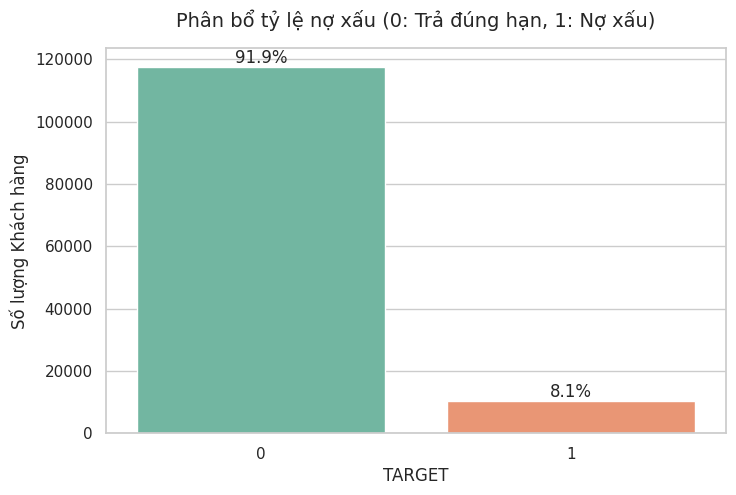

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='TARGET', hue='TARGET', palette='Set2', legend=False)
plt.title('Phân bổ tỷ lệ nợ xấu (0: Trả đúng hạn, 1: Nợ xấu)', fontsize=14, pad=15)
plt.ylabel('Số lượng Khách hàng')

# Hiển thị % trên từng cột
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

plt.show()

In [25]:
import matplotlib.pyplot as plt

plt.savefig('distribution_target.png', bbox_inches='tight', dpi=300)

<Figure size 640x480 with 0 Axes>

2. Khối lệnh trực quan hóa rủi ro theo Nhóm tuổi

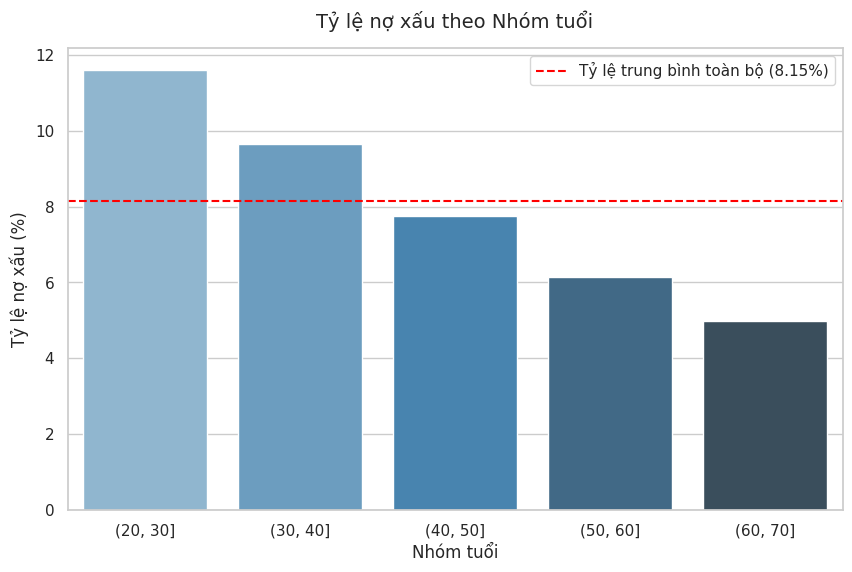

In [26]:
plt.figure(figsize=(10, 6))

# Chuyển đổi dữ liệu thống kê thành DataFrame để vẽ
age_target_df = df.groupby('AGE_GROUP', observed=False)['TARGET'].mean().reset_index()
age_target_df['TARGET_PERCENT'] = age_target_df['TARGET'] * 100

sns.barplot(data=age_target_df, x='AGE_GROUP', y='TARGET_PERCENT', hue='AGE_GROUP', palette='Blues_d', legend=False)
plt.title('Tỷ lệ nợ xấu theo Nhóm tuổi', fontsize=14, pad=15)
plt.xlabel('Nhóm tuổi')
plt.ylabel('Tỷ lệ nợ xấu (%)')

# Kẻ đường tham chiếu trung bình
mean_target = df['TARGET'].mean() * 100
plt.axhline(y=mean_target, color='red', linestyle='--', label=f'Tỷ lệ trung bình toàn bộ ({mean_target:.2f}%)')
plt.legend()

plt.show()

3. Khối lệnh trực quan hóa rủi ro theo Trình độ học vấn

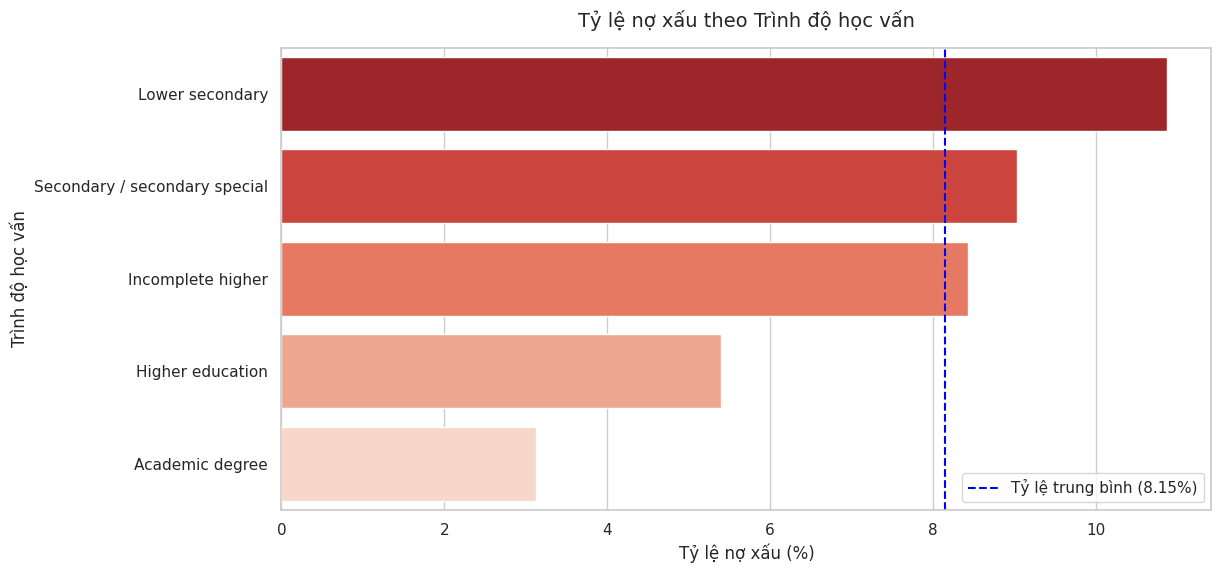

In [27]:
plt.figure(figsize=(12, 6))

edu_target_df = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().reset_index().sort_values('TARGET', ascending=False)
edu_target_df['TARGET_PERCENT'] = edu_target_df['TARGET'] * 100

sns.barplot(data=edu_target_df, x='TARGET_PERCENT', y='NAME_EDUCATION_TYPE', hue='NAME_EDUCATION_TYPE', palette='Reds_r', legend=False)
plt.title('Tỷ lệ nợ xấu theo Trình độ học vấn', fontsize=14, pad=15)
plt.xlabel('Tỷ lệ nợ xấu (%)')
plt.ylabel('Trình độ học vấn')

# Kẻ đường tham chiếu trung bình dọc
plt.axvline(x=mean_target, color='blue', linestyle='--', label=f'Tỷ lệ trung bình ({mean_target:.2f}%)')
plt.legend()

plt.show()